# Processor to crop and register multiplane data
* input:
  *  path: path to 3D or 4D stack in tiff format
  *  calpath: path to calibration file
  *    
* output:
  *  4D stack, order
  *  calibration file
  *  processing log file


In [1]:
from multiplane import MultiplaneProcess

# Initialize the MultiplaneProcess class
proc = MultiplaneProcess()

In [2]:
# choose path via gui or direct input  
proc.select_data_directory()

'F:/moritz/Technical_paper/4x2_scoptonics/20260422_livecell/beadstack/PS_e561nm_dz20nm_1'

In [3]:
# get metadata if present
proc.get_files_with_metadata()
proc.get_metadata()
proc.update_metadata()

Updated zstage displacement per frame to: 20.0 nm
Updated global ROI to:  [335, 1320, 2020, 580]
Updated exposure time to:  100.0  ms


In [4]:
proc.P['nplanes']= 8
proc.P['ncams']= 2
proc.P['ref_plane']= 2
#proc.P['order_default']= [3,2,1,0,4,5,6,7] 
proc.P['use_projection'] = 'median'  #'median' max min
proc.th_weight = 0.0001
proc.i_corr = False #  apply intensity correction
proc.P['padding'] = -10
proc.P["apply_transform"]= False
proc.deskew_cam = False

In [5]:
# activate logging
proc.set_logging(True)

Read image PS_e561nm_dz20nm_1_MMStack_Pos0.ome.tif; size (401, 2, 580, 2020); type uint16
Using global ROI [335, 1320, 2020, 580] from parameters, might be erroneous due to missing metadata
Using global ROI [335, 1320, 2020, 580] from parameters, might be erroneous due to missing metadata
Adaptive thresholding cam 0..


e:\GitHub\mp_proc\multiplane.py:597: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  eroded_mask = skim.morphology.binary_erosion(binary_mask, skim.morphology.square(3))


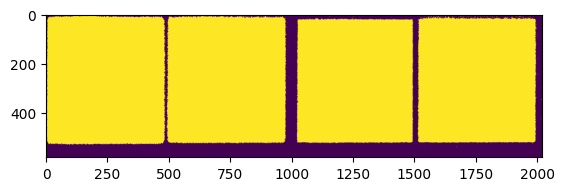

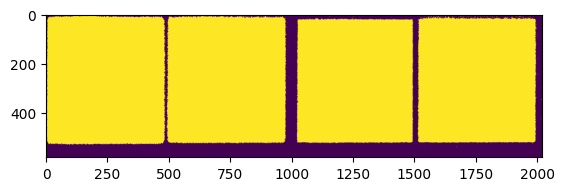

Adaptive thresholding cam 1..


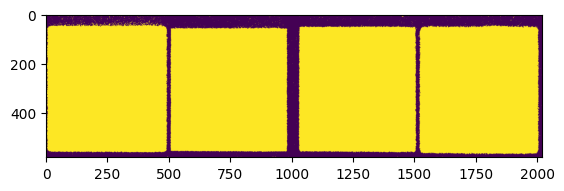

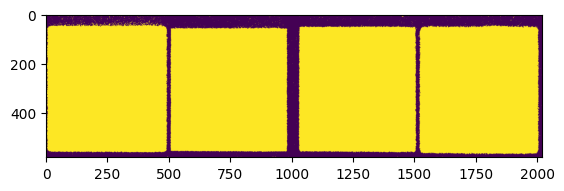

FOV size consolidation: 100%|██████████| 2/2 [00:02<00:00,  1.40s/it]


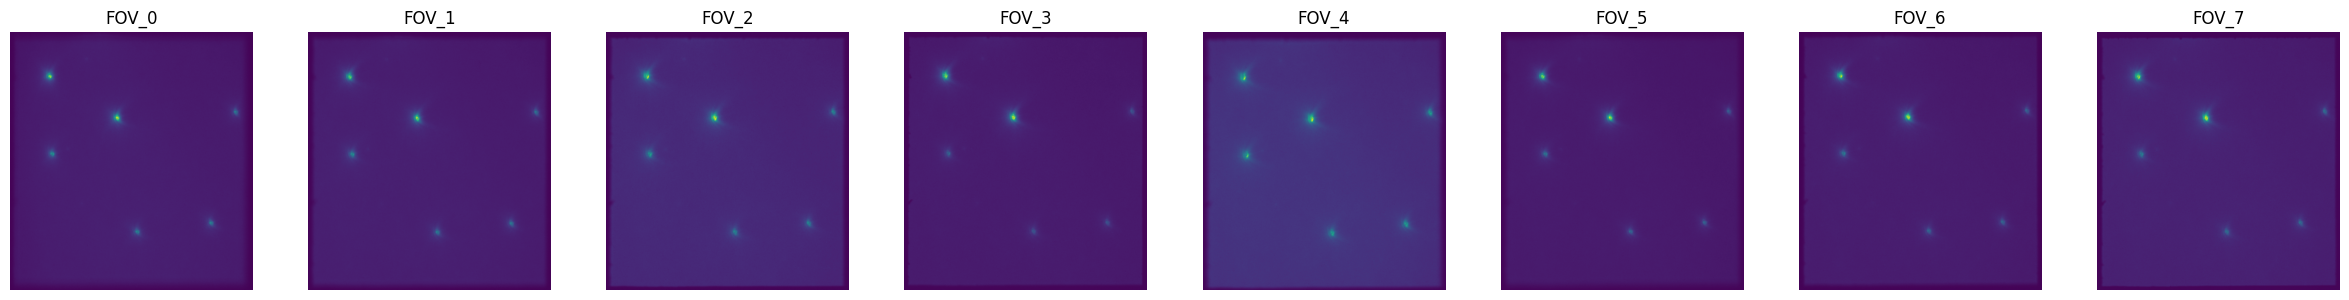

Updated zstage displacement per frame to: 20.0 nm
Updated global ROI to:  [335, 1320, 2020, 580]
Updated exposure time to:  100.0  ms
Estimating interplane distance..


SR-localising peaks:  25%|██▌       | 2/8 [00:00<00:01,  5.38it/s]

Skipped 0 / 2406 (0.00%) peaks in fitting due to irregular shape.
Skipped 0 / 2406 (0.00%) peaks in fitting due to irregular shape.


SR-localising peaks:  50%|█████     | 4/8 [00:00<00:00,  5.11it/s]

Skipped 0 / 2807 (0.00%) peaks in fitting due to irregular shape.
Skipped 0 / 2406 (0.00%) peaks in fitting due to irregular shape.


...

SR-localising peaks:  88%|████████▊ | 7/8 [00:01<00:00,  4.62it/s]

Skipped 0 / 2807 (0.00%) peaks in fitting due to irregular shape.
Skipped 0 / 2807 (0.00%) peaks in fitting due to irregular shape.


Convert datastructure: 100%|██████████| 8/8 [00:00<00:00, 106.66it/s]


Determining relative z-distances and order
{'dz': [np.float64(301.1268635996956), np.float64(191.22048670512925), np.float64(353.75134333337456), np.float64(227.28065537836812), np.float64(372.41111814040664), np.float64(228.93080590382056), np.float64(345.886678194708)], 'labels': ['1-0', '2-1', '3-2', '4-3', '5-4', '6-5', '7-6'], 'fp': [99, 114, 124, 142, 153, 172, 183, 200]}
Finished writing F:/moritz/Technical_paper/4x2_scoptonics/20260422_livecell/beadstack/PS_e561nm_dz20nm_1\cal_data\interplane_distance.svg
Finished writing F:/moritz/Technical_paper/4x2_scoptonics/20260422_livecell/beadstack/PS_e561nm_dz20nm_1\cal_data\interplane_distance.png
Using order [4 2 7 3 6 1 5 0]
Using quad based transformation estimation, whole quad combination sampling


Finding markers:  75%|███████▌  | 6/8 [00:00<00:00, 56.59it/s]

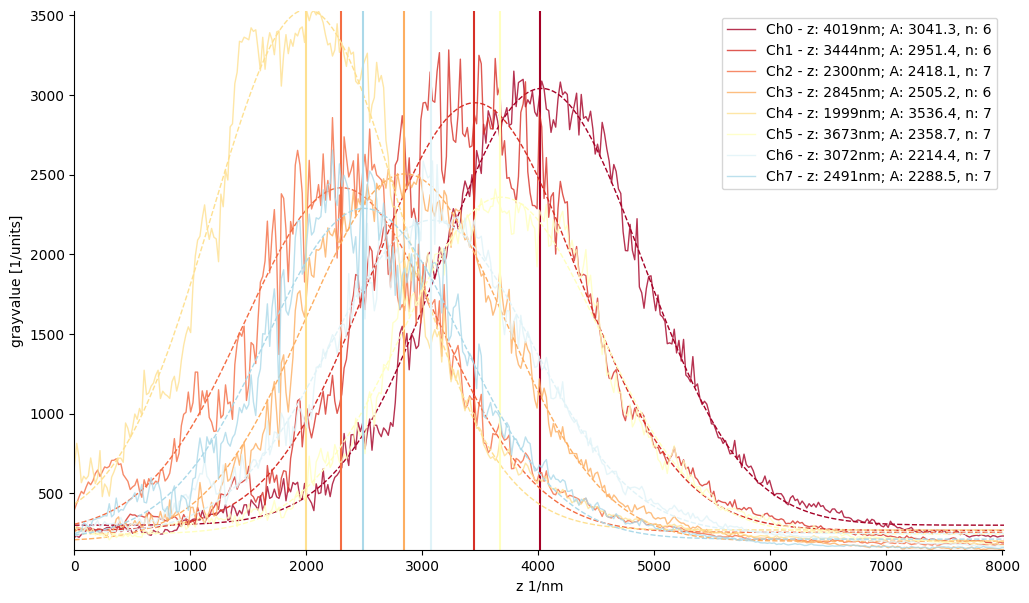

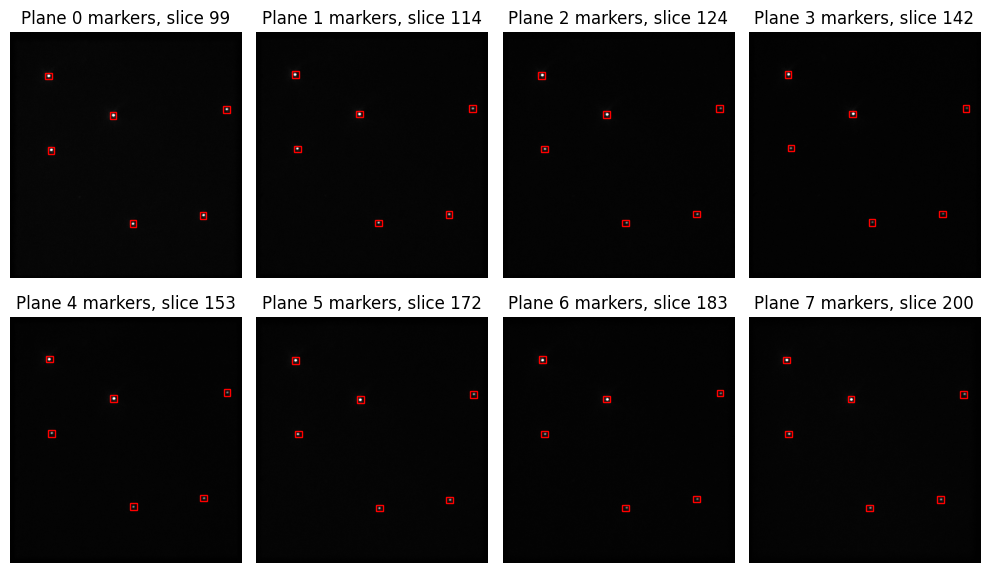

Finding markers: 100%|██████████| 8/8 [00:01<00:00,  7.95it/s]


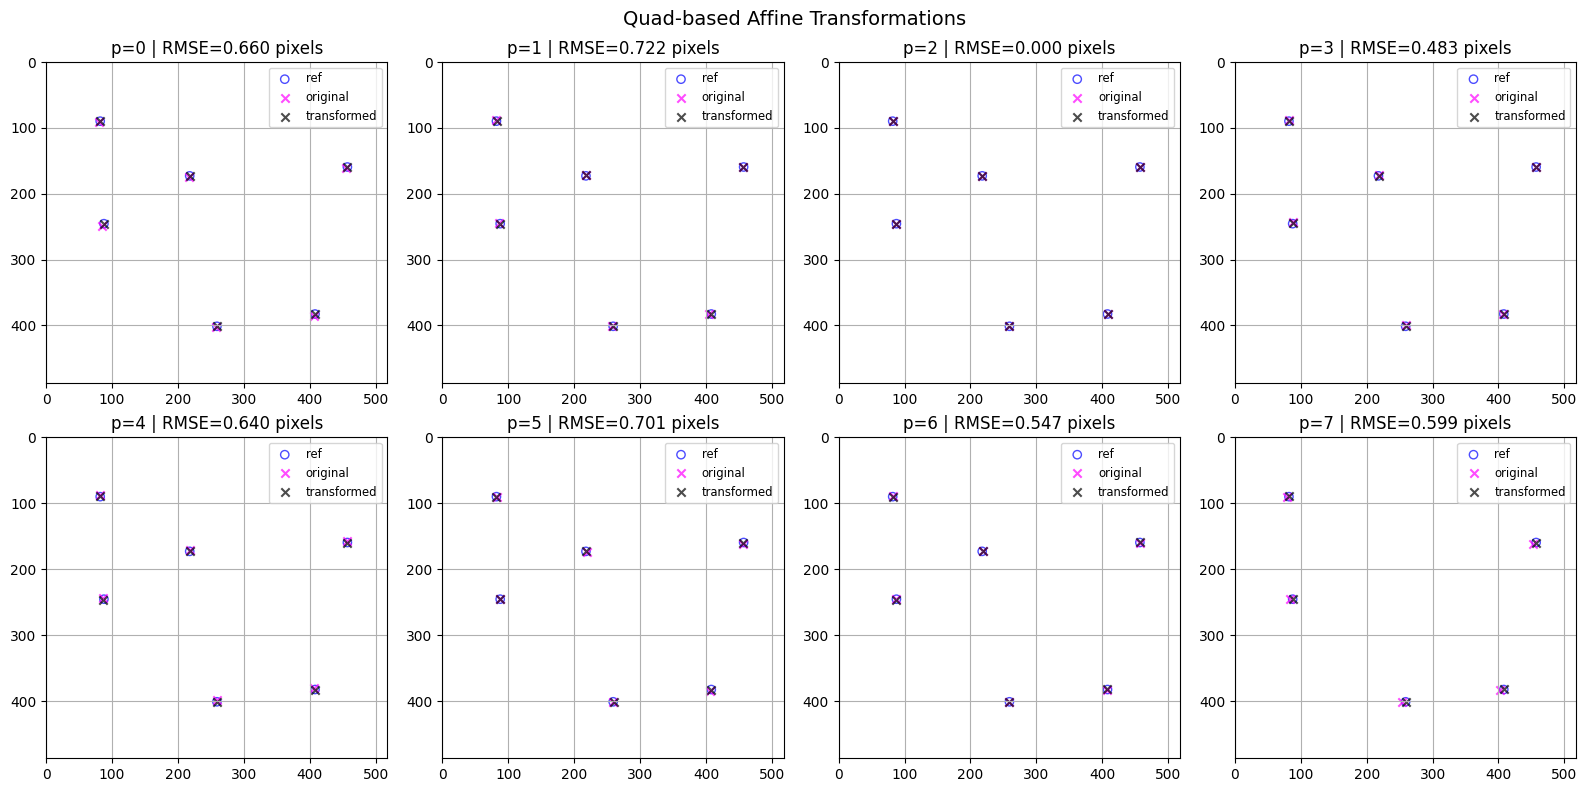

Query quads, estimate transform: 100%|██████████| 8/8 [00:01<00:00,  7.36it/s]

Checking magnification variance between planes...


Finished writing F:/moritz/Technical_paper/4x2_scoptonics/20260422_livecell/beadstack/PS_e561nm_dz20nm_1\cal_data\transform_error.png
Nothing to restructure in transform 0, skipping...
Nothing to restructure in transform 1, skipping...
Nothing to restructure in transform 2, skipping...
Nothing to restructure in transform 3, skipping...
Nothing to restructure in transform 4, skipping...
Nothing to restructure in transform 5, skipping...
Nothing to restructure in transform 6, skipping...
Nothing to restructure in transform 7, skipping...
Registration of data...
Processing parameters written to file
Finished writing marker plane 0
Finished writing marker plane 1
Finished writing marker plane 2
Finished writing marker plane 3
Finished writing marker plane 4
Finished writing marker plane 5
Finished writing marker plane 6
Finished writing marker plane 7


{'steps': 401,
 'dz_stage': np.float64(20.0),
 'pxlsize': 108,
 'ncams': 2,
 'fname': 'PS_e561nm_dz20nm_1_MMStack_Pos0.ome.tif',
 'mirror': [True, False, True, False, True, False, True, False],
 'dt': 100.0,
 'global_roi': {0: [335, 1320, 2020, 580], 1: [335, 1320, 2020, 580]},
 'fovs': {0: {0: [8, 1, 526, 488],
   1: [6, 492, 524, np.int64(979)],
   2: [8, 1512, 526, 1999],
   3: [11, 1015, 529, 1502]},
  1: {0: [40, 5, 558, 492],
   1: [48, 1520, 566, np.int64(2007)],
   2: [46, 1025, 564, 1512],
   3: [46, 502, 564, np.int64(989)]}},
 'deg': {0: 0, 1: 0},
 'dz': [np.float64(301.1268635996956),
  np.float64(191.22048670512925),
  np.float64(353.75134333337456),
  np.float64(227.28065537836812),
  np.float64(372.41111814040664),
  np.float64(228.93080590382056),
  np.float64(345.886678194708)],
 'order': array([4, 2, 7, 3, 6, 1, 5, 0]),
 'labels': ['1-0', '2-1', '3-2', '4-3', '5-4', '6-5', '7-6'],
 'fp': [99, 114, 124, 142, 153, 172, 183, 200],
 'brightness': {0: np.float64(1.0),
  1:

In [6]:
proc.calibrate(is_bead = True)          